# 03 · Exploratory analysis

This notebook does **not** walk through the variables one by one. It has a thesis
and defends it:

> The three strongest relationships in this dataset are **non-monotonic**, and in
> all three the correlation coefficient misleads. Selecting features by
> correlation would have discarded the best predictor available.

Everything below either supports that claim or qualifies it. Section 3 ends up
qualifying the thesis itself, which is the part worth reading twice.

In [2]:
import sys
sys.path.append("../src")

from config import bootstrap

ctx = bootstrap()
spark, w = ctx.spark, ctx.w

connected to Databricks
  branch   : sandbox
  catalog  : bank_churn_eng
  identity : juzoushio@...


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from config import UC_CATALOG, CAPACITY

pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 40)

plt.rcParams.update({
    "figure.dpi": 110, "figure.figsize": (9, 4.5),
    "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10,
})

SILVER_TABLE = f"{UC_CATALOG}.silver.customers_clean"

df = spark.table(SILVER_TABLE).toPandas()
df["exited"] = df["exited"].astype(bool)

BASE_RATE = df["exited"].mean()
N         = len(df)
N_CHURN   = int(df["exited"].sum())

print(f"{N:,} customers | {N_CHURN:,} churned | base rate {BASE_RATE:.2%}")

10,000 customers | 2,037 churned | base rate 20.37%


---

## 1 · Coverage matrix

Before arguing anything, check that no variable was left unexamined. The point of
declaring this **before** looking is that it turns "did I miss something?" into a
question with an answer.

Three gaps showed up. The third one changes a conclusion.

In [4]:
# Gap 1 - has_cr_card, never examined in any notebook so far
print("-- has_cr_card --")
print(df.groupby("has_cr_card")["exited"]
        .agg(churn=lambda s: round(s.mean()*100, 1), n="size").to_string())

print("\n-- has_cr_card within each age band, in case it hides structure --")
print(df.pivot_table(index="age_group", columns="has_cr_card",
                     values="exited", aggfunc="mean").round(3).to_string())

-- has_cr_card --
             churn     n
has_cr_card             
False         20.8  2945
True          20.2  7055

-- has_cr_card within each age band, in case it hides structure --
has_cr_card  False  True 
age_group                
18-29        0.075  0.076
30-39        0.102  0.112
40-49        0.307  0.308
50-59        0.587  0.548
60+          0.281  0.279


In [5]:
# Gap 2 - is the activity effect homogeneous across ages?
gap = (df.groupby(["age_group", "is_active_member"])["exited"].mean().unstack() * 100).round(1)
gap.columns = ["inactive", "active"]
gap["gap_pp"] = (gap["inactive"] - gap["active"]).round(1)

print("-- active/inactive gap within each age band --")
print(gap.sort_values("gap_pp", ascending=False).to_string())
print("\nThe gap is not constant. That is an interaction, and section 3 follows it.")

-- active/inactive gap within each age band --
           inactive  active  gap_pp
age_group                          
60+            85.6    12.5    73.1
50-59          81.2    37.1    44.1
40-49          38.0    22.6    15.4
30-39          13.6     8.2     5.4
18-29           9.8     5.4     4.4

The gap is not constant. That is an interaction, and section C follows it.


In [6]:
# Gap 3 - collinearity BETWEEN predictors, not against the target.
# Two predictors carrying the same information inflate each other's apparent
# importance and make coefficients unstable.
X = df[["credit_score", "age", "tenure", "balance",
        "num_of_products", "estimated_salary"]].copy()
X["is_active"]    = df["is_active_member"].astype(int)
X["has_card"]     = df["has_cr_card"].astype(int)
X["balance_zero"] = df["balance_zero"].astype(int)
X["is_german"]    = (df["geography"] == "Germany").astype(int)
X["is_female"]    = (df["gender"] == "Female").astype(int)

corr  = X.corr(method="spearman")
pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
strong = pairs[abs(pairs) > 0.3].sort_values(key=abs, ascending=False).round(3)

print("-- predictor pairs with |rho| > 0.3 --")
print(strong.to_string() if len(strong) else "  none")

-- predictor pairs with |rho| > 0.3 --
balance          balance_zero      -0.853
balance_zero     is_german         -0.436
balance          is_german          0.372
num_of_products  balance_zero       0.369
balance          num_of_products   -0.317


### Plot helpers

Two reusable functions, so the figures stay consistent instead of each one being
styled by hand.

The base-rate line appears in every chart on purpose. Without it a bar at 32% looks
alarming when the average is 20% — the reader needs the reference to judge the
number, and expecting them to remember it across nine figures is optimistic.

In [7]:
CHURN, SAFE, ACC, GREY = "#a8471f", "#2c5a72", "#8a5a08", "#78736a"
INK = "#1c1a17"

# A semi-transparent white box. This is what lets text sit on top of a bar
# without getting lost: the problem was never the colour, it was the background.
BOX = dict(boxstyle="round,pad=0.28", facecolor="white", edgecolor="none", alpha=0.82)


def base_line(ax, side="left", y=None):
    """Draw the base-rate line and label it on a white background."""
    y = BASE_RATE * 100 if y is None else y
    ax.axhline(y, color=GREY, ls="--", lw=1.2, zorder=1)
    x, ha = (0.012, "left") if side == "left" else (0.988, "right")
    # Deliberately BELOW the line: above it, the label collided with the bold percentages
    ax.text(x, y - 1.0, f"base rate {BASE_RATE:.1%}",
            transform=ax.get_yaxis_transform(), color=INK, fontsize=8.5,
            ha=ha, va="top", bbox=BOX, zorder=6)


def note(ax, text, xy, xytext, ha="left"):
    """An annotation with an arrow, on the same white box."""
    ax.annotate(text, xy=xy, xytext=xytext, fontsize=8.5, color=INK,
                ha=ha, va="center", bbox=BOX, zorder=7,
                arrowprops=dict(arrowstyle="->", color=CHURN, lw=1.2, shrinkA=2, shrinkB=4))


def churn_bars(pct, sizes, title, xlabel="", ax=None, side="left"):
    """Churn rate per category, with the sample size inside each bar."""
    if ax is None:
        _, ax = plt.subplots()
    x = np.arange(len(pct))
    ax.bar(x, pct.values, color=CHURN, zorder=2, width=0.62)
    for i, (v, n) in enumerate(zip(pct.values, sizes.values)):
        ax.text(i, v + 1.4, f"{v:.1f}%", ha="center", fontsize=9.5,
                fontweight="bold", color=INK, zorder=5)
        # n goes INSIDE the bar: outside, it competed with the percentage
        ax.text(i, max(v * 0.5, 2), f"n={n:,}", ha="center", fontsize=8,
                color="white", zorder=5)
    base_line(ax, side)
    ax.set_xticks(x); ax.set_xticklabels(pct.index, fontsize=9.5)
    ax.set_ylabel("% churn"); ax.set_xlabel(xlabel)
    ax.set_title(title, fontsize=11, pad=12)
    ax.set_ylim(0, max(pct.values) * 1.22)
    return ax


def heatmap(M, title, vlim, ax=None, cbar_label=""):
    if ax is None:
        _, ax = plt.subplots(figsize=(9.5, 7))
    im = ax.imshow(M.values, cmap="RdBu_r", vmin=-vlim, vmax=vlim, aspect="auto")
    ax.set_xticks(range(len(M.columns))); ax.set_xticklabels(M.columns, rotation=45, ha="right", fontsize=8.5)
    ax.set_yticks(range(len(M.index)));   ax.set_yticklabels(M.index, fontsize=8.5)
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            v = M.values[i, j]
            if abs(v) > 0.15:
                ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7.5,
                        color="white" if abs(v) > 0.55 else INK)
    ax.set_title(title, fontsize=11, pad=12)
    ax.grid(False)
    plt.colorbar(im, ax=ax, label=cbar_label, fraction=0.035)
    return ax

### Figure 1 · Collinearity between predictors

Printed as text the matrix is unreadable. As a heatmap the structure is obvious.

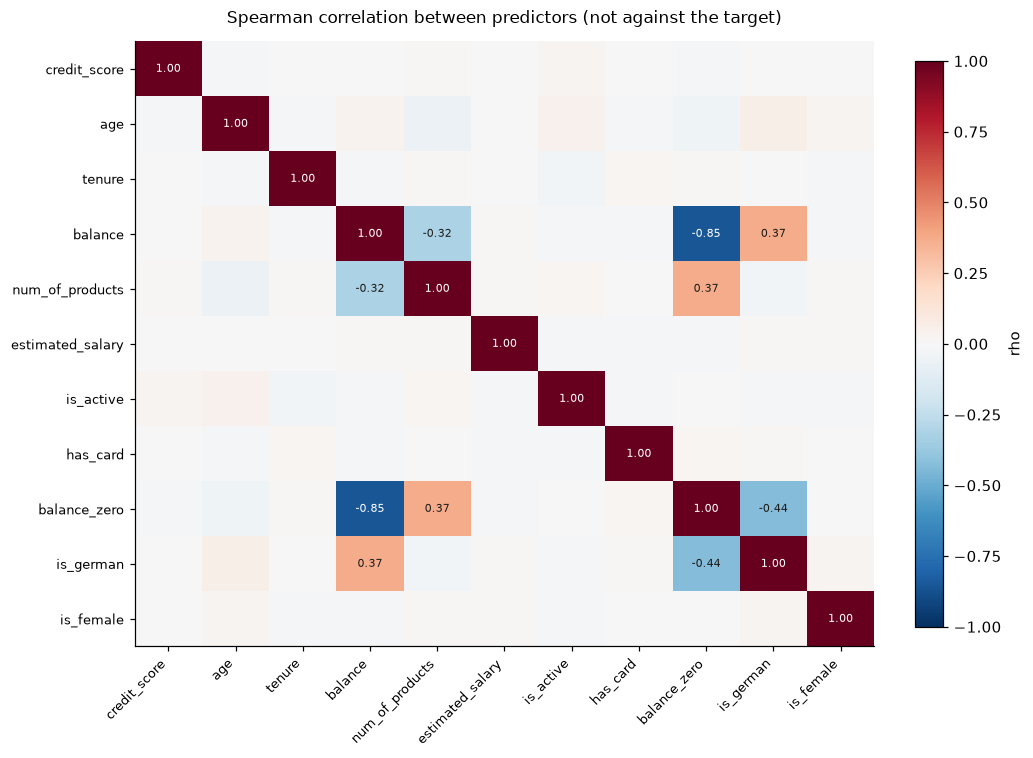

  balance <-> balance_zero   -0.853  (one derives from the other)
  balance_zero <-> is_german -0.436  (Germany has no zeros)
  is_active <-> everything   max 0.040  (orthogonal)

is_active_member carries information no other variable carries. Combined
with being the only actionable variable, that makes it the most valuable
column in the table -- and it is the one section C is about.


In [8]:
fig, ax = plt.subplots(figsize=(9.5, 7))
heatmap(corr, "Spearman correlation between predictors (not against the target)",
        vlim=1.0, ax=ax, cbar_label="rho")
plt.tight_layout(); plt.show()

print(f"  balance <-> balance_zero   {corr.loc['balance','balance_zero']:+.3f}  (one derives from the other)")
print(f"  balance_zero <-> is_german {corr.loc['balance_zero','is_german']:+.3f}  (Germany has no zeros)")
print(f"  is_active <-> everything   max {corr['is_active'].drop('is_active').abs().max():.3f}  (orthogonal)")
print()
print("is_active_member carries information no other variable carries. Combined")
print("with being the only actionable variable, that makes it the most valuable")
print("column in the table -- and it is the one section 3 is about.")

---

## 2 · The thesis: three strong, non-monotonic relationships

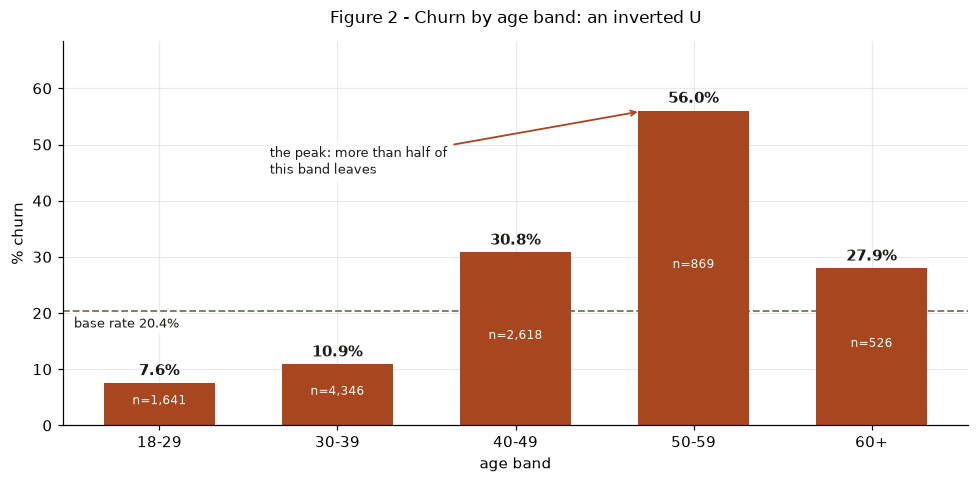

Spearman age vs exited: +0.3240
Actual range: 7.6% to 56.0%  (48.5 points)


In [9]:
tab_age = (df.groupby("age_group")
             .agg(pct=("exited", lambda s: s.mean()*100), n=("exited", "size"))
             .reindex(["18-29","30-39","40-49","50-59","60+"]))

ax = churn_bars(tab_age["pct"], tab_age["n"],
                "Figure 2 - Churn by age band: an inverted U",
                xlabel="age band")
note(ax, "the peak: more than half of\nthis band leaves", xy=(2.72, 56.0), xytext=(0.62, 47))
plt.tight_layout(); plt.show()

rho_age = df["age"].corr(df["exited"].astype(int), method="spearman")
print(f"Spearman age vs exited: {rho_age:+.4f}")
print(f"Actual range: {tab_age['pct'].min():.1f}% to {tab_age['pct'].max():.1f}%  "
      f"({tab_age['pct'].max() - tab_age['pct'].min():.1f} points)")

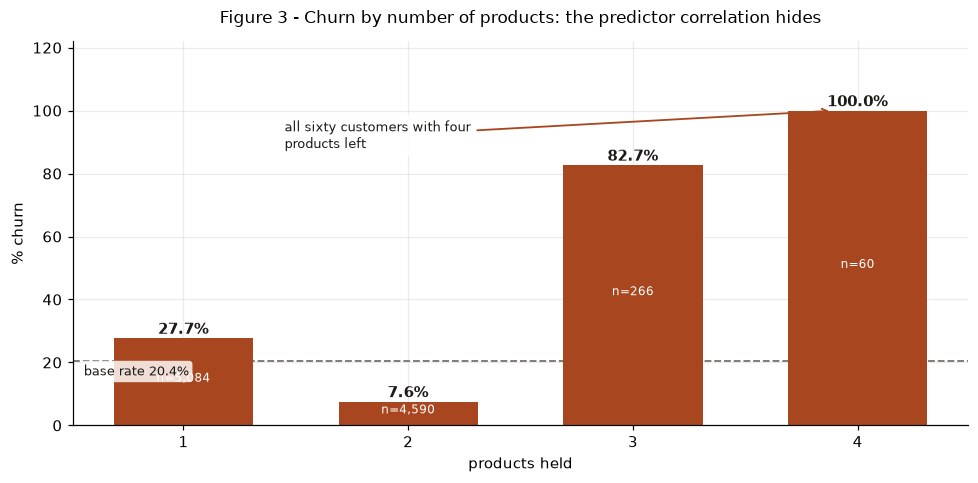

Spearman num_of_products vs exited: -0.1253   <-- weak and NEGATIVE
Actual range: 7.6% to 100.0%  (92.4 points)


In [10]:
tab_prod = (df.groupby("num_of_products")
              .agg(pct=("exited", lambda s: s.mean()*100), n=("exited", "size")))

ax = churn_bars(tab_prod["pct"], tab_prod["n"],
                "Figure 3 - Churn by number of products: the predictor correlation hides",
                xlabel="products held")
note(ax, "all sixty customers with four\nproducts left", xy=(2.9, 100.0), xytext=(0.45, 92))
plt.tight_layout(); plt.show()

rho_prod = df["num_of_products"].corr(df["exited"].astype(int), method="spearman")
print(f"Spearman num_of_products vs exited: {rho_prod:+.4f}   <-- weak and NEGATIVE")
print(f"Actual range: {tab_prod['pct'].min():.1f}% to {tab_prod['pct'].max():.1f}%  "
      f"({tab_prod['pct'].max() - tab_prod['pct'].min():.1f} points)")

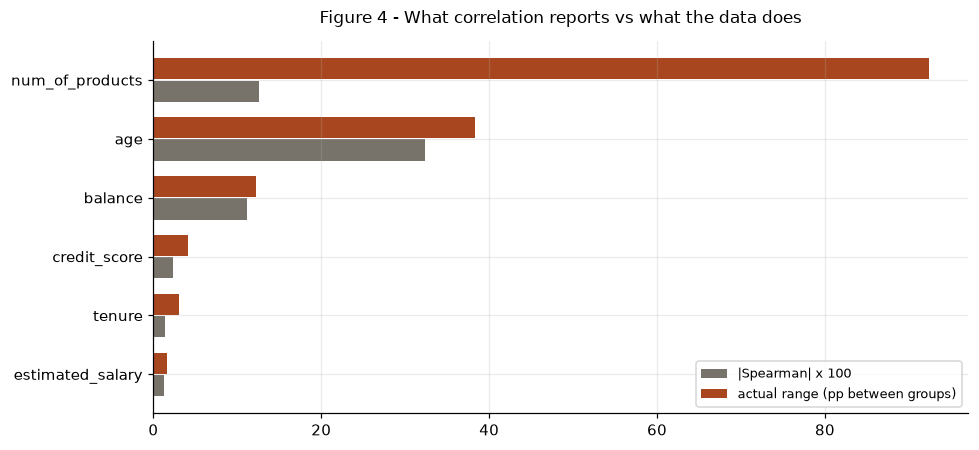

                  abs_rho  range_pp
variable                           
estimated_salary    0.012     1.600
tenure              0.014     3.085
credit_score        0.023     4.163
balance             0.111    12.200
age                 0.324    38.311
num_of_products     0.125    92.418


In [11]:
# Figure 4 - what the correlation says against what the data shows
vars_comp = ["age", "num_of_products", "balance", "credit_score",
             "estimated_salary", "tenure"]
rows = []
for v in vars_comp:
    rho = df[v].corr(df["exited"].astype(int), method="spearman")
    q = pd.qcut(df[v], 5, duplicates="drop") if df[v].nunique() > 10 else df[v]
    spread = df.groupby(q, observed=True)["exited"].mean()
    rows.append({"variable": v, "abs_rho": abs(rho),
                 "range_pp": (spread.max() - spread.min()) * 100})

comp = pd.DataFrame(rows).set_index("variable").sort_values("range_pp")

fig, ax = plt.subplots(figsize=(9, 4.2))
y = np.arange(len(comp))
ax.barh(y - 0.19, comp["abs_rho"] * 100, height=0.36, color=GREY, label="|Spearman| x 100")
ax.barh(y + 0.19, comp["range_pp"],      height=0.36, color=CHURN, label="actual range (pp between groups)")
ax.set_yticks(y); ax.set_yticklabels(comp.index, fontsize=9.5)
ax.set_title("Figure 4 - What correlation reports vs what the data does", fontsize=11, pad=12)
ax.legend(fontsize=8.5, loc="lower right")
plt.tight_layout(); plt.show()

print(comp.round(3).to_string())

### What figures 2 to 4 establish

`num_of_products` spans **92 points** between groups — from 7.6% to 100% — and its
Spearman correlation is **−0.05**. A feature-selection step filtering on
|rho| > 0.1 would have deleted the strongest predictor in the table.

The reason is mechanical: correlation measures monotonicity. Risk falls from one
product to two and then explodes at three and four. Averaged over the whole range,
the ups cancel the downs and the coefficient lands near zero.

**This is already an argument about model choice**, made before any model exists.
A linear model needs to be told about a shape like this; a tree finds it by itself.

---

## 3 · The main finding: the age × activity interaction

Section 1 turned up something that forces the previous thesis to be revised.

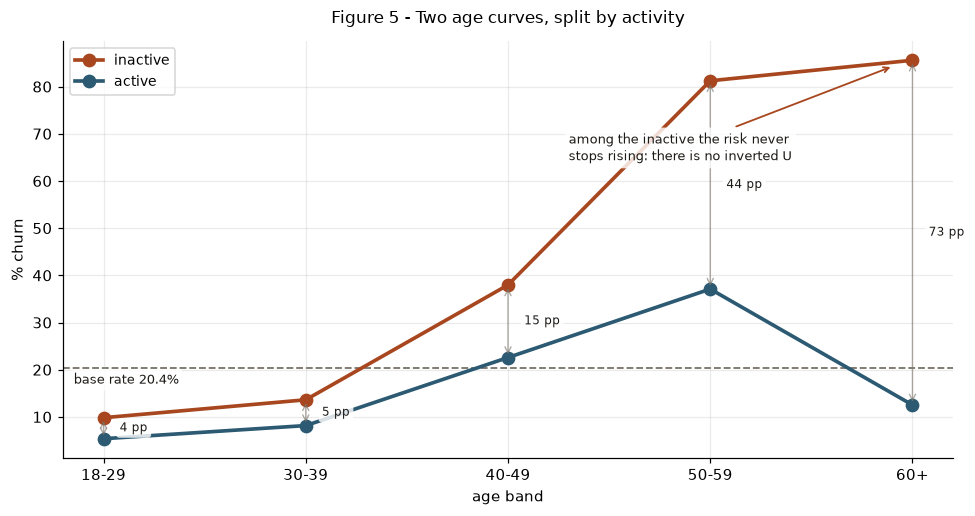

           inactive  active
age_group                  
18-29           9.8     5.4
30-39          13.6     8.2
40-49          38.0    22.6
50-59          81.2    37.1
60+            85.6    12.5


In [12]:
piv = (df.pivot_table(index="age_group", columns="is_active_member",
                      values="exited", aggfunc="mean")
         .reindex(["18-29","30-39","40-49","50-59","60+"]) * 100)
piv.columns = ["inactive", "active"]

fig, ax = plt.subplots(figsize=(9, 4.8))
x = np.arange(5)
ax.plot(x, piv["inactive"], "o-", color=CHURN, lw=2.4, ms=8, label="inactive", zorder=3)
ax.plot(x, piv["active"],   "o-", color=SAFE,  lw=2.4, ms=8, label="active",   zorder=3)

# Base rate goes left, where both curves sit far below it. On the right it
# collided with the annotation.
base_line(ax, "left")

for i, (a, b) in enumerate(zip(piv["inactive"], piv["active"])):
    ax.annotate("", xy=(i, a), xytext=(i, b),
                arrowprops=dict(arrowstyle="<->", color=GREY, lw=0.9, alpha=0.6))
    ax.text(i + 0.08, (a + b) / 2, f"{a-b:.0f} pp", fontsize=8, color=INK,
            va="center", bbox=BOX, zorder=5)

note(ax, "among the inactive the risk never\nstops rising: there is no inverted U",
     xy=(3.92, 84.6), xytext=(2.30, 67))

ax.set_xticks(x); ax.set_xticklabels(piv.index)
ax.set_ylabel("% churn"); ax.set_xlabel("age band")
ax.set_title("Figure 5 - Two age curves, split by activity", fontsize=11, pad=12)
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

print(piv.round(1).to_string())

### The third confounder, and the one with the biggest consequences

It was taken as established that age describes an inverted U: risk climbs to the
50-59 band and then falls. **That is false, and it is a composition artefact.**

Split by activity, the picture is different:

- **Among the inactive**, risk never stops climbing — it reaches 85.6% past 60.
- **Among the active**, it does fall after 60.
- The inverted U in the aggregate appears only because the proportion of active
  customers changes across age bands.

Two consequences follow, and both are decisions rather than observations.

**On modelling.** A model that treats age additively cannot represent this. It has
to capture an interaction, which is an argument for trees over linear models — made
here, from the data, rather than from preference.

**On the business.** The highest-risk cell in the entire dataset is *inactive and
over 60*, at 85.6%. And activity is the one variable the bank can actually change.
Age is observed; inactivity is fought.

In [13]:
# Figure 6 - practical rules against the pre-registered baseline
def evaluate(mask, name, quota=CAPACITY):
    sub = df[mask]
    if len(sub) > quota:
        rate = sub["exited"].mean()
        contacts, caught = quota, quota * rate
    else:
        contacts, caught = len(sub), sub["exited"].sum()
        left = quota - contacts
        if left > 0:
            outside = df[~mask]
            contacts += left
            caught   += left * outside["exited"].mean()
    return {"rule": name, "contacts": int(contacts), "caught": int(caught),
            "precision_pct": round(caught / contacts * 100, 1),
            "pct_of_churn": round(caught / N_CHURN * 100, 1)}

rules = [
    evaluate(df["age_group"].isin(["40-49", "50-59"]), "age 40-59 (notebook 00)"),
    evaluate(~df["is_active_member"], "inactive only"),
    evaluate(~df["is_active_member"] & df["age_group"].isin(["50-59", "60+"]),
             "inactive AND over 50"),
    evaluate(df["products_group"] == "3+", "three or more products"),
]

res = pd.DataFrame(rules).set_index("rule")
print(res.to_string())
print(f"\nThe bar the model has to clear is the best of these: {res['caught'].max()} churners")
print("captured within 800 contacts. Not the age rule, and certainly not random.")

                         contacts  caught  precision_pct  pct_of_churn
rule                                                                  
age 40-59 (notebook 00)       800     296           37.1          14.6
inactive only                 800     214           26.9          10.5
inactive AND over 50          800     452           56.6          22.2
three or more products        800     366           45.8          18.0

The bar the model has to clear is the best of these: 452 churners
captured within 800 contacts. Not the age rule, and certainly not random.


### The bar goes up

The criterion pre-registered in notebook 00 stands, but the baseline it points at
is stronger than the age rule alone. The two-variable rule — **inactive and over
50** — is what a competent analyst would come up with in an afternoon, and it is
what the model actually has to beat.

Raising your own bar after finding a better baseline is uncomfortable and correct.
The alternative is beating a rival chosen for being easy.

---

## 4 · The sensitive variables

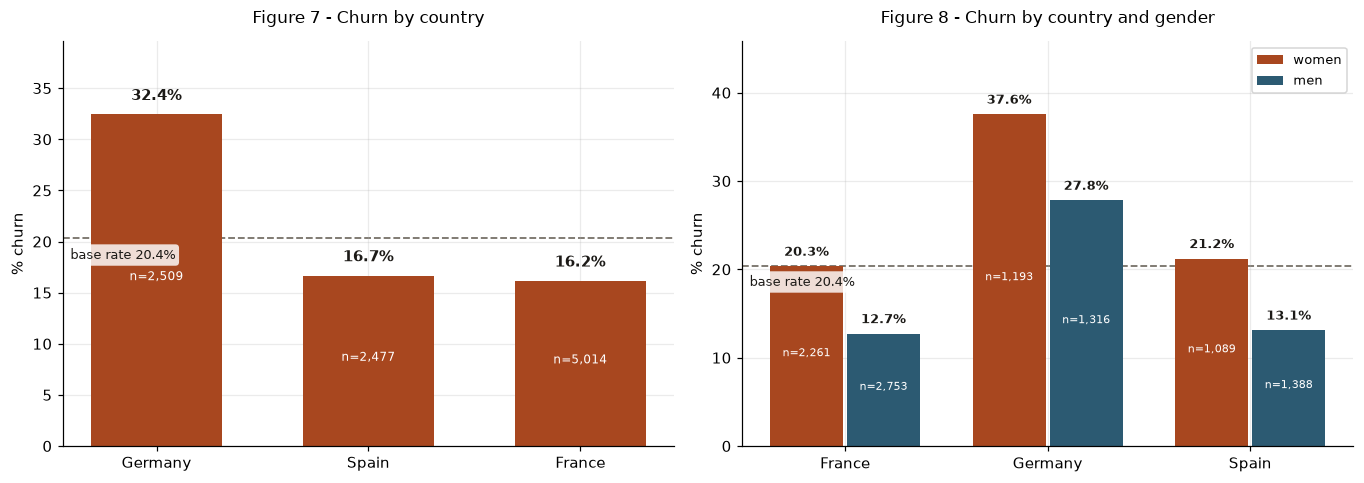

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5))

tab_geo = (df.groupby("geography")
             .agg(pct=("exited", lambda s: s.mean()*100), n=("exited", "size"))
             .sort_values("pct", ascending=False))
churn_bars(tab_geo["pct"], tab_geo["n"], "Figure 7 - Churn by country", ax=axes[0])

# Same format as the left panel: bold percentage with the symbol, sample size
# inside the bar, base rate labelled. Two charts side by side have to be read
# the same way or the comparison costs the reader effort.
gg = (df.pivot_table(index="geography", columns="gender", values="exited", aggfunc="mean") * 100)
nn = df.pivot_table(index="geography", columns="gender", values="exited", aggfunc="size")

ax = axes[1]
x = np.arange(len(gg))
for k, (col, colour, lbl) in enumerate([("Female", CHURN, "women"), ("Male", SAFE, "men")]):
    off = -0.19 if k == 0 else 0.19
    ax.bar(x + off, gg[col], width=0.36, color=colour, label=lbl, zorder=2)
    for i, v in enumerate(gg[col].values):
        ax.text(i + off, v + 1.2, f"{v:.1f}%", ha="center", fontsize=8.5,
                fontweight="bold", color=INK, zorder=5)
        ax.text(i + off, max(v * 0.5, 2), f"n={nn[col].values[i]:,}", ha="center",
                fontsize=7.5, color="white", zorder=5)
base_line(ax, "left")
ax.set_xticks(x); ax.set_xticklabels(gg.index)
ax.set_ylabel("% churn")
ax.set_title("Figure 8 - Churn by country and gender", fontsize=11, pad=12)
ax.legend(fontsize=8.5)
ax.set_ylim(0, gg.values.max() * 1.22)

plt.tight_layout(); plt.show()

### Real effects with no available explanation

Germany churns at twice the rate of France and Spain while being
**indistinguishable on every observable variable**: same mean age, same share of
active customers, same product counts. Women churn at 25.1% against 16.5% for men,
and the gap replicates inside all three countries, so it is not a country effect
wearing a disguise.

Both variables predict well **precisely because they stand in for something not
measured**. That is what makes them dangerous rather than useful: using them means
allocating a benefit on the basis of a characteristic whose mechanism cannot be
stated.

The decision on whether to use them belongs in notebook 05, where the cost of
excluding them gets measured. Deciding here, without that number, would be a
posture.

---

## 5 · Inferential analysis

Two tests, chosen deliberately: one that **should reject** the null and one that
**should not**. A section where everything rejects proves only that the sample is
large.

### Why chi-squared

The variables coming up are categorical on both sides — `is_active_member`,
`products_group` and `tenure` against `exited`. For that case the test is the
chi-squared test of independence. It compares the observed frequency table against
the one that would appear if the two variables had nothing to do with each other,
and measures how far apart they are.

The test has a validity condition: **no expected cell below 5**. That is why the
function prints the minimum expected frequency. If it drops under 5 the p-value
stops being reliable and categories have to be merged. It is printed to be checked,
not for decoration.

Alongside each test, **Cramér's V** answers the question that actually matters.
Chi-squared says *whether* there is a relationship; V says *how much*. With 10,000
rows the first almost always says yes.

In [15]:
from scipy import stats


def chi2_test(var, name):
    table = pd.crosstab(df[var], df["exited"])
    chi2, p, dof, expected = stats.chi2_contingency(table)
    n_tot = table.values.sum()
    cramer = np.sqrt(chi2 / (n_tot * (min(table.shape) - 1)))
    print(f"-- {name} --")
    print(f"  chi2 = {chi2:8.2f}   dof = {dof}   p = {p:.3e}")
    print(f"  Cramer V = {cramer:.4f}   minimum expected frequency = {expected.min():.1f}")
    print(f"  {'REJECTS' if p < 0.05 else 'DOES NOT REJECT'} independence (alpha = 0.05)\n")
    return {"variable": name, "chi2": round(chi2, 2), "p": p,
            "cramer_v": round(cramer, 4), "rejects": p < 0.05}


print("Test 1 - tenure. Expected NOT to reject")
r1 = chi2_test("tenure", "tenure vs exited")

print("Test 2 - is_active_member. Expected to reject clearly")
r2 = chi2_test("is_active_member", "is_active_member vs exited")

print("Test 3 - products_group")
r3 = chi2_test("products_group", "products_group vs exited")

Test 1 - tenure. Expected NOT to reject
-- tenure vs exited --
  chi2 =    13.90   dof = 10   p = 1.776e-01
  Cramer V = 0.0373   minimum expected frequency = 84.1
  DOES NOT REJECT independence (alpha = 0.05)

Test 2 - is_active_member. Expected to reject clearly
-- is_active_member vs exited --
  chi2 =   242.99   dof = 1   p = 8.786e-55
  Cramer V = 0.1559   minimum expected frequency = 987.7
  REJECTS independence (alpha = 0.05)

Test 3 - products_group
-- products_group vs exited --
  chi2 =  1494.60   dof = 2   p = 0.000e+00
  Cramer V = 0.3866   minimum expected frequency = 66.4
  REJECTS independence (alpha = 0.05)



### Why Mann-Whitney and not Student's t

Age is numeric, so chi-squared does not apply. The default choice would be
Student's t, which compares two means — but the t test **assumes normality**, and
the distributions here are not normal.

Mann-Whitney does not need that assumption. Instead of comparing means it ranks
every value from lowest to highest and compares **positions**: if the leavers
systematically occupied the high ranks, the test detects it. Working on ranks
rather than raw values makes the shape of the distribution irrelevant.

The p-value alone would say little, again because of sample size. So it is reported
with the **rank-biserial correlation**, which runs from −1 to +1 and does measure
the strength of the separation.

In [16]:
a = df.loc[df["exited"],  "age"]
b = df.loc[~df["exited"], "age"]
u, p_u = stats.mannwhitneyu(a, b, alternative="two-sided")

r_rb = 1 - (2 * u) / (len(a) * len(b))

print("-- Mann-Whitney U: age, leavers vs stayers --")
print(f"  median leavers : {a.median():.0f} years   (n = {len(a):,})")
print(f"  median stayers : {b.median():.0f} years   (n = {len(b):,})")
print(f"  U = {u:,.0f}   p = {p_u:.3e}")
print(f"  rank-biserial correlation = {r_rb:+.4f}")
print(f"  {'REJECTS' if p_u < 0.05 else 'DOES NOT REJECT'} equality of distributions")

summary = pd.DataFrame([r1, r2, r3]).set_index("variable")
print("\n-- summary --")
print(summary.to_string())

-- Mann-Whitney U: age, leavers vs stayers --
  median leavers : 45 years   (n = 2,037)
  median stayers : 36 years   (n = 7,963)
  U = 11,874,650   p = 3.210e-230
  rank-biserial correlation = -0.4641
  REJECTS equality of distributions

-- summary --
                               chi2             p  cramer_v  rejects
variable                                                            
tenure vs exited              13.90  1.775846e-01    0.0373    False
is_active_member vs exited   242.99  8.785858e-55    0.1559     True
products_group vs exited    1494.60  0.000000e+00    0.3866     True


### Interpretation

The test on `tenure` **does not reject** independence: there is no evidence of an
association between tenure and churn. That is a negative result and it is reported
as one. It also reinforces the earlier conclusion that tenure came from a uniform
draw.

`is_active_member` and `products_group` reject comfortably. But look at **Cramér's
V** rather than the p-value alone: with 10,000 observations almost any difference
comes out significant, and V is what says whether the effect is large enough to act
on.

> **Obligatory caveat:** all of this is **association**. No test of independence
> establishes causality. That inactivity and churn travel together does not show
> that inactivity causes churn — it could run the other way, or a third factor
> could drive both.

---

## Summary

**Thesis confirmed.** The three strongest relationships are non-monotonic, and in
all three the correlation misleads. `num_of_products` spans 92 points with a
coefficient of −0.05.

**Thesis qualified.** The inverted U in age is a composition artefact. Split by
activity, risk among the inactive never stops rising.

**The bar is now higher.** The rival to beat is "inactive and over 50", not the age
rule, and definitely not random.

**Two effects with no explanation.** Germany and gender both predict well while
being indistinguishable on every observable variable. Their cost gets measured in
notebook 05.

**Next:** `04_modeling`.